In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

In [3]:
df = pd.read_csv('knn.csv')
df

,Weight(x2),Height(y2),Class
0,51,167,Underweight
1,66,177,Normal
2,75,169,Overweight
3,69,176,Normal
4,50,173,Underweight
5,82,170,Overweight
6,65,172,Normal
7,58,180,Underweight
8,68,162,Overweight
9,63,165,Normal


In [4]:
df.describe()

,Weight(x2),Height(y2)
count,25.00000,25.000000
mean,64.44000,172.480000
std,9.62237,6.532738
min,50.00000,162.000000
25%,57.00000,168.000000
50%,65.00000,173.000000
75%,72.00000,178.000000
max,82.00000,183.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Weight(x2)  25 non-null     int64 
 1   Height(y2)  25 non-null     int64 
 2   Class       25 non-null     object
dtypes: int64(2), object(1)
memory usage: 732.0+ bytes


In [7]:
df['Class'].value_counts()

Class
Normal         10
Underweight     8
Overweight      7
Name: count, dtype: int64

In [11]:
df.isnull().sum()

Weight(x2)    0
Height(y2)    0
Class         0
dtype: int64

In [8]:
df.head()

,Weight(x2),Height(y2),Class
0,51,167,Underweight
1,66,177,Normal
2,75,169,Overweight
3,69,176,Normal
4,50,173,Underweight


In [10]:
X = df[['Weight(x2)','Height(y2)']]
y = df['Class']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
n_neighbors=5

In [17]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

In [18]:
knn_model.fit(
    X_train_scaled,
    y_train
)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [20]:
y_pred = knn_model.predict(X_test_scaled)

y_pred

array(['Overweight', 'Normal', 'Underweight', 'Underweight',
       'Underweight', 'Normal', 'Normal', 'Normal'], dtype=object)

In [23]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[3 0 2]
 [1 1 0]
 [0 0 1]]


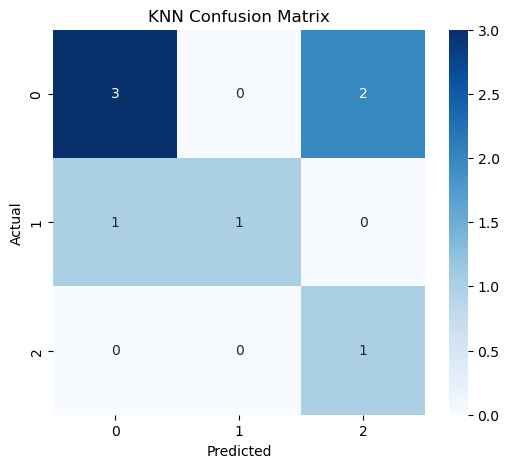

In [24]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [25]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

      Normal       0.75      0.60      0.67         5
  Overweight       1.00      0.50      0.67         2
 Underweight       0.33      1.00      0.50         1

    accuracy                           0.62         8
   macro avg       0.69      0.70      0.61         8
weighted avg       0.76      0.62      0.65         8

